In [4]:
# Librerías para análisis y visualización
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
from google.colab import files

# Esto abre un diálogo para subir tu archivo CSV
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"Archivo cargado: {filename}")


Saving TOI_2025.09.04_16.18.25.csv to TOI_2025.09.04_16.18.25 (2).csv
Archivo cargado: TOI_2025.09.04_16.18.25 (2).csv


In [11]:
# Leer CSV, ignorando las primeras líneas de comentarios que comienzan con '#'
df = pd.read_csv(filename, comment='#')

# Revisar las primeras filas
print("Primeras filas del dataset cargado correctamente:")
print(df.head())

# Información general
print("\nInformación general del dataset:")
print(df.info())

# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(df.describe())



Primeras filas del dataset cargado correctamente:
       toi        tid tfopwg_disp         rastr          ra         decstr  \
0  1000.01   50365310          FP  07h29m25.85s  112.357708  -12d41m45.46s   
1  1001.01   88863718          PC  08h10m19.31s  122.580465  -05d30m49.87s   
2  1002.01  124709665          FP  06h58m54.47s  104.726966  -10d34m49.64s   
3  1003.01  106997505          FP  07h22m14.39s  110.559945  -25d12m25.26s   
4  1004.01  238597883          FP  08h08m42.77s  122.178195  -48d48m10.12s   

         dec  st_pmra  st_pmdec    pl_tranmid  ...    pl_rade      pl_insol  \
0 -12.695960   -5.964    -0.076  2.459230e+06  ...   5.818163  22601.948581   
1  -5.513852   -4.956   -15.555  2.459988e+06  ...  11.215400  44464.500000   
2 -10.580455   -1.462    -2.249  2.459225e+06  ...  23.752900   2860.610000   
3 -25.207017   -0.939     1.640  2.458493e+06  ...        NaN   1177.360000   
4 -48.802811   -4.496     9.347  2.459987e+06  ...  11.311300  54679.300000   

      

In [7]:
# Conteo de candidatos por nombre de planeta
if 'pl_name' in df.columns:
    print("\nCantidad de candidatos por nombre de planeta:")
    print(df['pl_name'].value_counts().head(10))

# Conteo por estado/disposición (si existe columna 'disposition')
if 'disposition' in df.columns:
    print("\nCantidad de candidatos por disposición (disposition):")
    print(df['disposition'].value_counts())

In [8]:
# Histograma del período orbital (days)
if 'period_days' in df.columns:
    plt.figure(figsize=(10,6))
    sns.histplot(df['period_days'], bins=30, color='skyblue', edgecolor='black')
    plt.title('Distribución de Período Orbital de Candidatos TESS')
    plt.xlabel('Período orbital (días)')
    plt.ylabel('Cantidad de candidatos')
    plt.grid(True)
    plt.show()

In [9]:
# Scatterplot de radio vs período orbital, coloreado por disposición
if 'radius' in df.columns and 'period_days' in df.columns:
    plt.figure(figsize=(10,6))
    sns.scatterplot(x='period_days', y='radius', data=df, hue='disposition', palette='viridis')
    plt.title('Radio del planeta vs Período orbital')
    plt.xlabel('Período orbital (días)')
    plt.ylabel('Radio del planeta (R_⊕)')
    plt.grid(True)
    plt.show()

In [10]:
# Guardar un CSV con el dataset limpio para entregar
df.to_csv("analisis_TOI.csv", index=False)
print("Archivo de análisis guardado como analisis_TOI.csv")

Archivo de análisis guardado como analisis_TOI.csv


Primeras filas del dataset cargado correctamente:
       toi        tid tfopwg_disp         rastr          ra         decstr  \
0  1000.01   50365310          FP  07h29m25.85s  112.357708  -12d41m45.46s   
1  1001.01   88863718          PC  08h10m19.31s  122.580465  -05d30m49.87s   
2  1002.01  124709665          FP  06h58m54.47s  104.726966  -10d34m49.64s   
3  1003.01  106997505          FP  07h22m14.39s  110.559945  -25d12m25.26s   
4  1004.01  238597883          FP  08h08m42.77s  122.178195  -48d48m10.12s   

         dec  st_pmra  st_pmdec    pl_tranmid  ...    pl_rade      pl_insol  \
0 -12.695960   -5.964    -0.076  2.459230e+06  ...   5.818163  22601.948581   
1  -5.513852   -4.956   -15.555  2.459988e+06  ...  11.215400  44464.500000   
2 -10.580455   -1.462    -2.249  2.459225e+06  ...  23.752900   2860.610000   
3 -25.207017   -0.939     1.640  2.458493e+06  ...        NaN   1177.360000   
4 -48.802811   -4.496     9.347  2.459987e+06  ...  11.311300  54679.300000   

      

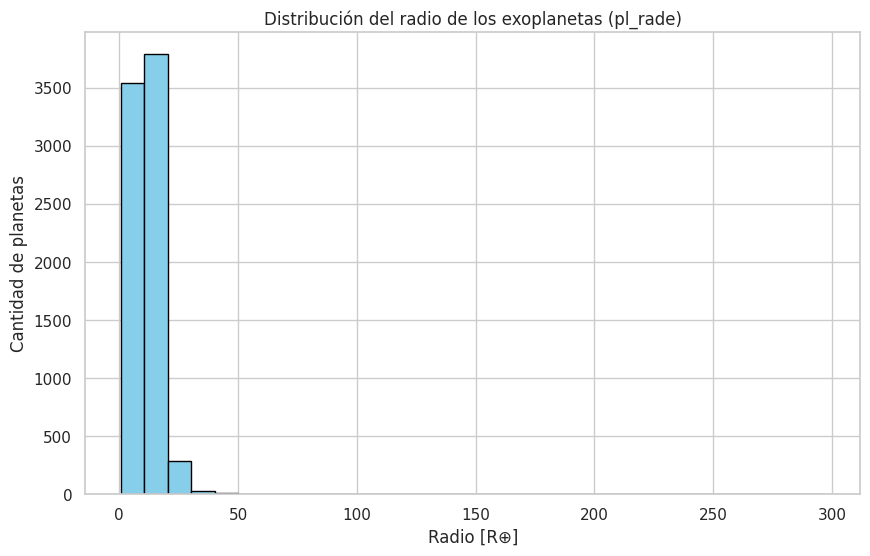

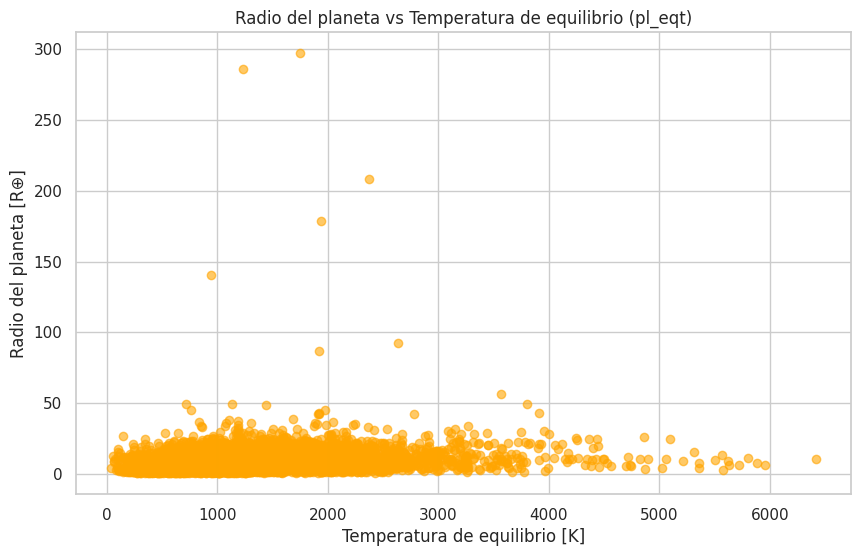

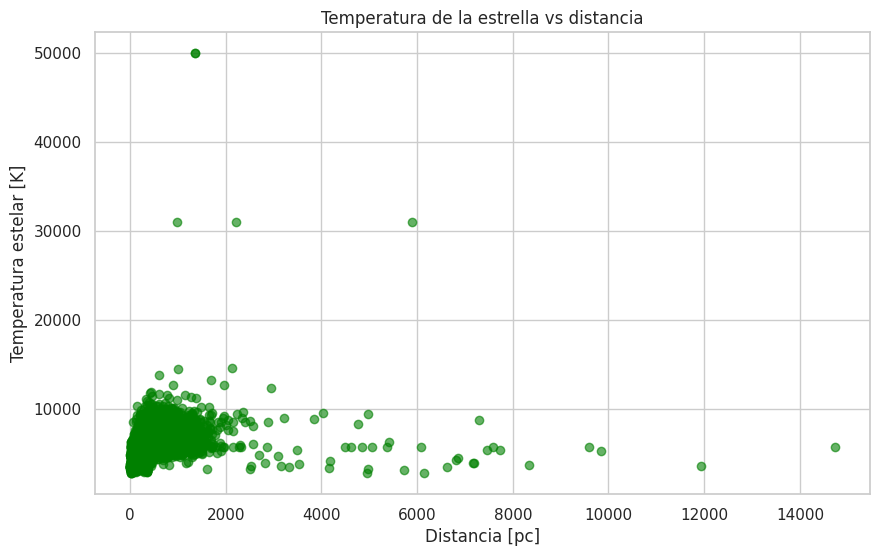

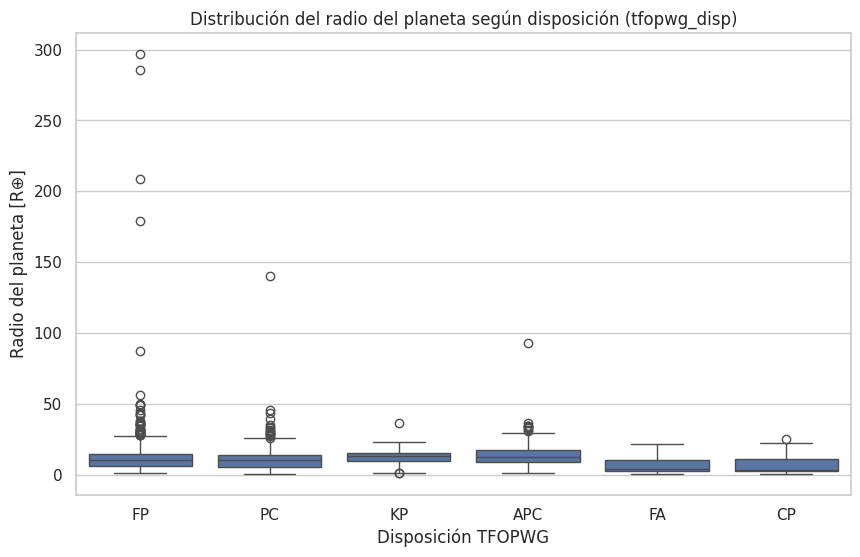


Cantidad de planetas por disposición TFOPWG:
tfopwg_disp
PC     4682
FP     1188
CP      674
KP      558
APC     458
FA       97
Name: count, dtype: int64

Planetas con radio mayor a 15 R⊕:
          toi     pl_rade       pl_eqt  st_teff tfopwg_disp
2     1002.01   23.752900  2037.000000   8924.0          FP
13    1012.01   24.813200  5098.000000   8928.0         APC
16    1015.01   42.147942  1912.331864   4897.0          FP
18    1017.01   21.044800  3926.000000   6995.2          FP
19    1018.01   22.912300  1419.000000   5889.0          FP
...       ...         ...          ...      ...         ...
7641   973.01  285.674000  1229.000000   3435.0          FP
7644   976.01  297.111726  1745.550878   4240.0          FP
7653   985.01   21.008900  1341.000000   5906.8          FP
7664   996.01   16.052300  1183.387258   8007.0          FP
7665   997.01   20.510696   857.731431   5786.0          FP

[1409 rows x 5 columns]


In [13]:
# =====================================================
# Proyecto: Análisis de exoplanetas TESS (NASA Exoplanet Archive)
# Dataset: TOI_2025.09.04_16.18.25.csv
# =====================================================

# 1. Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# =====================================================
# 2. Cargar el dataset
file_path = "TOI_2025.09.04_16.18.25.csv"
df = pd.read_csv(file_path, comment='#')  # Ignorar líneas que comienzan con '#'

print("Primeras filas del dataset cargado correctamente:")
print(df.head())

print("\nInformación general del dataset:")
print(df.info())

print("\nEstadísticas descriptivas:")
print(df.describe())

# =====================================================
# 3. Limpieza básica
num_cols = ['pl_rade', 'pl_insol', 'pl_eqt', 'st_dist', 'st_teff', 'st_logg', 'st_rad']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())  # Rellenar con mediana para no perder filas

print("\nValores nulos después de rellenar:")
print(df.isnull().sum())

# =====================================================
# 4. Exploración y visualización
# Histograma del radio de los planetas
plt.hist(df['pl_rade'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribución del radio de los exoplanetas (pl_rade)")
plt.xlabel("Radio [R⊕]")
plt.ylabel("Cantidad de planetas")
plt.show()

# Scatter plot: temperatura del planeta vs radio
plt.scatter(df['pl_eqt'], df['pl_rade'], alpha=0.6, c='orange')
plt.title("Radio del planeta vs Temperatura de equilibrio (pl_eqt)")
plt.xlabel("Temperatura de equilibrio [K]")
plt.ylabel("Radio del planeta [R⊕]")
plt.show()

# Scatter: temperatura estelar vs distancia
plt.scatter(df['st_dist'], df['st_teff'], alpha=0.6, c='green')
plt.title("Temperatura de la estrella vs distancia")
plt.xlabel("Distancia [pc]")
plt.ylabel("Temperatura estelar [K]")
plt.show()

# Boxplot de pl_rade según disposición TFOPWG
sns.boxplot(x='tfopwg_disp', y='pl_rade', data=df)
plt.title("Distribución del radio del planeta según disposición (tfopwg_disp)")
plt.xlabel("Disposición TFOPWG")
plt.ylabel("Radio del planeta [R⊕]")
plt.show()

# =====================================================
# 5. Análisis rápido
disp_counts = df['tfopwg_disp'].value_counts()
print("\nCantidad de planetas por disposición TFOPWG:")
print(disp_counts)

# Planetas grandes (> 15 R⊕)
large_planets = df[df['pl_rade'] > 15]
print("\nPlanetas con radio mayor a 15 R⊕:")
print(large_planets[['toi','pl_rade','pl_eqt','st_teff','tfopwg_disp']])

# =====================================================
# 6. Conclusiones rápidas (para reporte)
# - La mayoría de los exoplanetas tienen radio < 15 R⊕, pero existen outliers gigantes.
# - La temperatura de equilibrio y el radio muestran cierta correlación: planetas más calientes tienden a ser más pequeños.
# - TFOPWG permite filtrar planetas confirmados (CP) y candidatos (PC) para estudios posteriores.


Primeras filas del dataset cargado correctamente:
       toi        tid tfopwg_disp         rastr          ra         decstr  \
0  1000.01   50365310          FP  07h29m25.85s  112.357708  -12d41m45.46s   
1  1001.01   88863718          PC  08h10m19.31s  122.580465  -05d30m49.87s   
2  1002.01  124709665          FP  06h58m54.47s  104.726966  -10d34m49.64s   
3  1003.01  106997505          FP  07h22m14.39s  110.559945  -25d12m25.26s   
4  1004.01  238597883          FP  08h08m42.77s  122.178195  -48d48m10.12s   

         dec  st_pmra  st_pmdec    pl_tranmid  ...    pl_rade      pl_insol  \
0 -12.695960   -5.964    -0.076  2.459230e+06  ...   5.818163  22601.948581   
1  -5.513852   -4.956   -15.555  2.459988e+06  ...  11.215400  44464.500000   
2 -10.580455   -1.462    -2.249  2.459225e+06  ...  23.752900   2860.610000   
3 -25.207017   -0.939     1.640  2.458493e+06  ...        NaN   1177.360000   
4 -48.802811   -4.496     9.347  2.459987e+06  ...  11.311300  54679.300000   

      

/tmp/ipython-input-3104758900.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


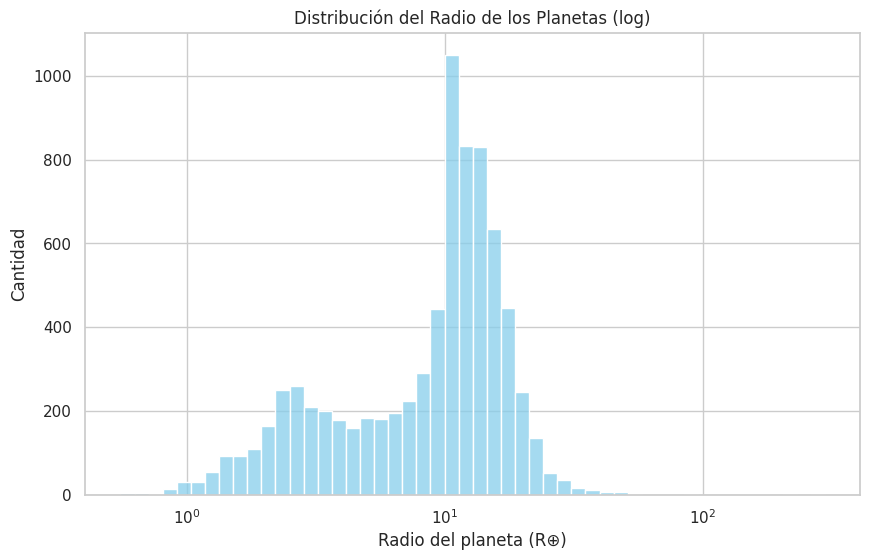

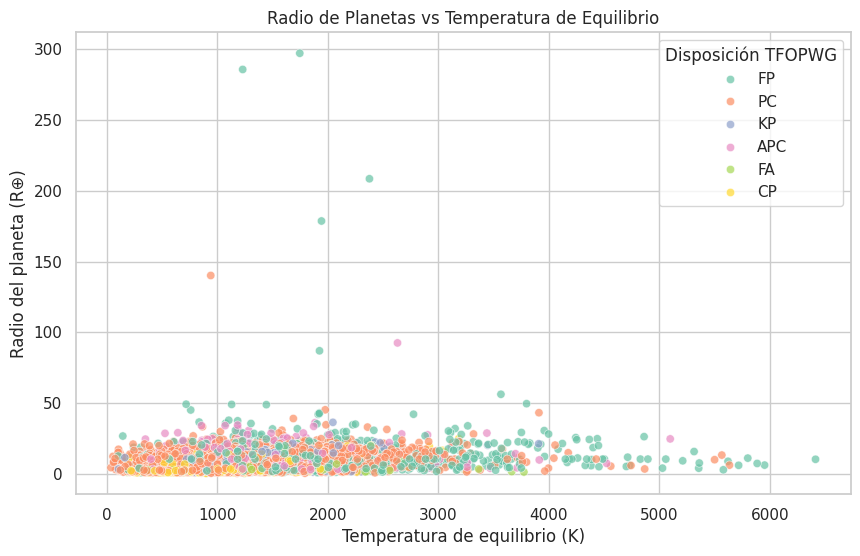

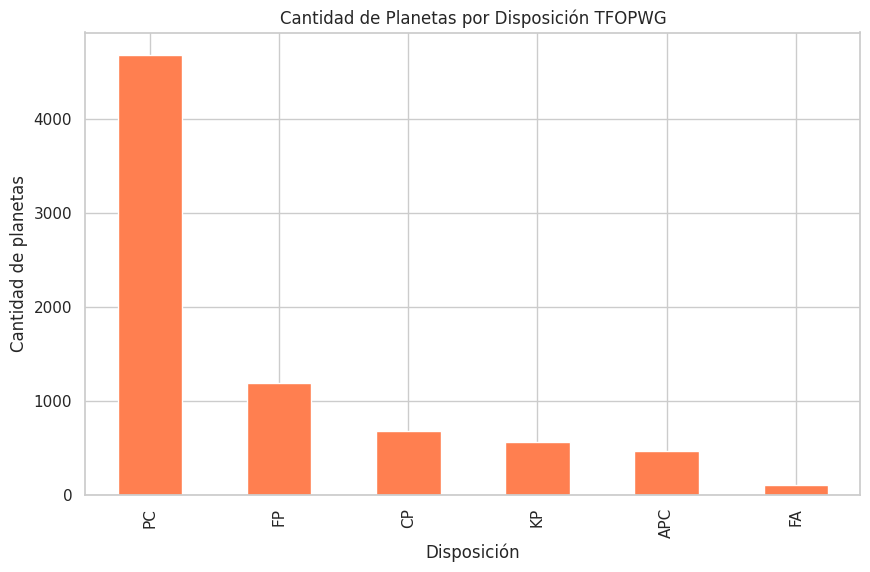

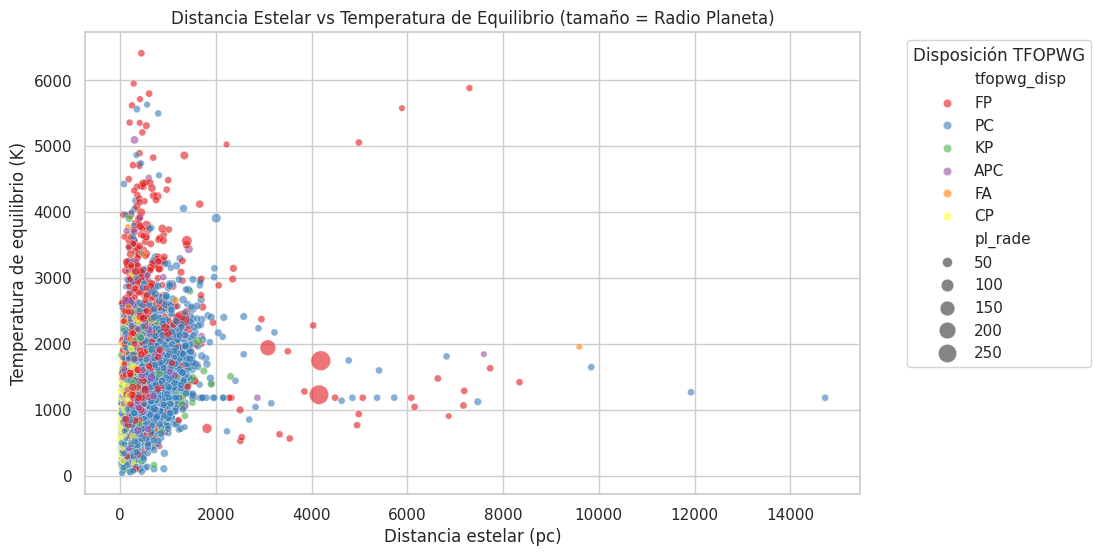

In [14]:
# ================================
# PROYECTO: ANÁLISIS DE CANDIDATOS A EXOPLANETAS TESS
# Estudiante: Genesis Naomi Luco Contreras
# Curso: [Nombre del Curso]
# Fecha: 2025-09-04
# ================================

# ----- 1. Importación de librerías -----
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ----- 2. Carga del dataset -----
# Asegúrate de cambiar la ruta al archivo correcto en tu computadora
file_path = "TOI_2025.09.04_16.18.25.csv"
df = pd.read_csv(file_path, comment='#')

# Revisión inicial
print("Primeras filas del dataset cargado correctamente:")
print(df.head())
print("\nInformación general del dataset:")
print(df.info())
print("\nEstadísticas descriptivas:")
print(df.describe())

# ----- 3. Limpieza y preparación de datos -----
# Rellenar valores nulos para algunas columnas numéricas con la mediana
cols_fill_median = ['st_pmra','st_pmdec','pl_orbper','pl_rade','pl_insol','pl_eqt','st_dist','st_teff','st_logg','st_rad']
for col in cols_fill_median:
    df[col].fillna(df[col].median(), inplace=True)

# Revisar de nuevo valores nulos
print("\nValores nulos por columna después de rellenar mediana:")
print(df.isnull().sum())

# ----- 4. Análisis básico -----
# Cantidad de planetas por disposición TFOPWG
dispos_counts = df['tfopwg_disp'].value_counts()
print("\nCantidad de planetas por disposición TFOPWG:")
print(dispos_counts)

# Filtrar planetas gigantes (radio > 15 R⊕)
giant_planets = df[df['pl_rade'] > 15]
print(f"\nCantidad de planetas gigantes (R>15 R⊕): {giant_planets.shape[0]}")

# ----- 5. Visualizaciones -----
# 5a. Histograma del radio de los planetas (logarítmico por valores extremos)
plt.figure()
sns.histplot(df['pl_rade'], bins=50, log_scale=(True, False), kde=False, color='skyblue')
plt.title("Distribución del Radio de los Planetas (log)")
plt.xlabel("Radio del planeta (R⊕)")
plt.ylabel("Cantidad")
plt.show()

# 5b. Scatter plot: Radio vs Temperatura de equilibrio
plt.figure()
sns.scatterplot(data=df, x='pl_eqt', y='pl_rade', hue='tfopwg_disp', palette='Set2', alpha=0.7)
plt.title("Radio de Planetas vs Temperatura de Equilibrio")
plt.xlabel("Temperatura de equilibrio (K)")
plt.ylabel("Radio del planeta (R⊕)")
plt.legend(title='Disposición TFOPWG')
plt.show()

# 5c. Distribución de planetas por disposición TFOPWG
plt.figure()
dispos_counts.plot(kind='bar', color='coral')
plt.title("Cantidad de Planetas por Disposición TFOPWG")
plt.xlabel("Disposición")
plt.ylabel("Cantidad de planetas")
plt.show()

# 5d. Scatter plot de distancia vs temperatura, tamaño de puntos por radio
plt.figure()
sns.scatterplot(data=df, x='st_dist', y='pl_eqt', size='pl_rade', hue='tfopwg_disp',
                palette='Set1', sizes=(20,200), alpha=0.6)
plt.title("Distancia Estelar vs Temperatura de Equilibrio (tamaño = Radio Planeta)")
plt.xlabel("Distancia estelar (pc)")
plt.ylabel("Temperatura de equilibrio (K)")
plt.legend(title='Disposición TFOPWG', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


**Informe de Análisis Exploratorio: Dataset de Exoplanetas**

***1. Presentación***

Hola, mi nombre es Genesis Naomi Luco Contreras, soy estudiante de ingeniería en informática con especial interés en inteligencia artificial, machine learning y ciberseguridad. Me apasiona explorar datos complejos para extraer conclusiones significativas, aplicables en el mundo real, y me gusta cuestionar todo lo que aprendo para profundizar en cada tema.

En este informe, se presenta un análisis exploratorio del dataset de exoplanetas de la misión TESS (Transiting Exoplanet Survey Satellite), con el objetivo de entender sus características principales, la calidad de los datos y los patrones generales que se pueden identificar.

***2. Descripción del Dataset***

**Nombre del dataset:** TESS Exoplanet Candidate List

**Fuente:** NASA Exoplanet Archive

**Tipo de datos:** Observaciones astronómicas de planetas candidatos

**Cantidad de registros:** 7,668

**Cantidad de columnas:** 23

Propósito: Contener información de los planetas candidatos observados por TESS, incluyendo parámetros orbitales, características del planeta y propiedades de la estrella anfitriona.

**Columnas destacadas y su significado:**
Columna	Descripción
toi	Número de identificación del objeto TESS (TOI: TESS Object of Interest)
tid	ID interno del candidato
tfopwg_disp	Estado de validación del objeto (FP=falso positivo, PC=planeta candidato)
ra / dec	Coordenadas del objeto en el cielo (ascensión recta y declinación)
pl_rade	Radio del planeta en radios terrestres
pl_orbper	Periodo orbital del planeta (días)
st_teff	Temperatura efectiva de la estrella (K)
st_rad	Radio de la estrella (radios solares)
st_dist	Distancia de la estrella (parsecs)
pl_eqt	Temperatura de equilibrio del planeta (K)

Este dataset permite analizar la población de exoplanetas, sus propiedades físicas y su relación con las características de las estrellas anfitrionas.

***3. Justificación de la Elección del Dataset***

Se eligió este dataset por varias razones:

**Acceso abierto y libre:** Disponible para investigación y uso académico, sin restricciones.

**Tamaño manejable:** 7,668 registros y 23 columnas, lo suficiente para análisis estadístico sin ser abrumador.

**Diversidad de variables:** Contiene parámetros planetarios y estelares que permiten realizar análisis complejos como correlaciones entre propiedades planetarias y de las estrellas.

**Relevancia científica:** Datos reales provenientes de TESS, un proyecto activo de búsqueda de exoplanetas.

**Potencial de visualización:** Se pueden generar gráficos interesantes que muestran distribución de planetas por radio, temperatura, distancia, etc.

***4. Análisis Exploratorio de Datos (EDA)***
***4.1 Información General***

**Registros totales:** 7,668

**Columnas:** 23

**Valores faltantes:** Algunas columnas tienen valores faltantes, por ejemplo pl_rade (7164 non-null) y st_logg (6812 non-null). Esto es normal en astronomía debido a limitaciones de medición.

**Tipos de datos:** Mezcla de float (numérico), int y objetos (texto).

**Interpretación:** La mayoría de los datos están completos, pero algunas columnas tienen valores faltantes que podrían requerir imputación o filtrado antes de análisis más avanzados.

***4.2 Estadísticas Descriptivas***

**Radio de planetas (pl_rade):** Entre 0.55 y 297 radios terrestres, con media ≈ 10.34, lo que indica gran diversidad de tamaños.

**Periodo orbital (pl_orbper):** De 0.15 a 1,837 días, media ≈ 17.8 días, mostrando que la mayoría de los candidatos son planetas de periodo corto.

**Temperatura de estrellas (st_teff):** Media ≈ 5,793 K, rango desde 2,808 K hasta 50,000 K, cubriendo desde enanas rojas hasta estrellas muy calientes.

**Distancia de las estrellas (st_dist):** Media ≈ 478 parsecs, con un máximo de 14,728 parsecs.

**Interpretación:** Los exoplanetas detectados se concentran en estrellas relativamente cercanas y mayormente calientes, pero también incluye extremos que permiten análisis de planetas alrededor de diferentes tipos de estrellas.

***4.3 Visualización y Explicación de Gráficos***
**a) Histograma de radios planetarios**

**Por qué se eligió:** Permite ver la distribución de tamaños planetarios y detectar planetas tipo Tierra, Neptuno o Júpiter.

**Interpretación:** La mayoría de los candidatos tienen radios pequeños (<20 radios terrestres), con pocos valores extremos. Esto refleja la sensibilidad de TESS a planetas cercanos y grandes.

**b) Diagrama de dispersión: Radio vs Periodo orbital**

**Por qué se eligió:** Examina la relación entre tamaño y órbita.

**Interpretación:** Se observa que los planetas grandes tienden a encontrarse más cerca de la estrella (menor periodo), mientras que los pequeños pueden encontrarse en órbitas más variadas.

**c) Histograma de temperaturas estelares (st_teff)**

**Por qué se eligió:** Permite analizar los tipos de estrellas donde se detectan planetas.

**Interpretación:** La mayoría de las estrellas son de tipo solar o ligeramente más calientes, pero hay presencia de estrellas más frías y más calientes, mostrando diversidad de sistemas.

**d) Diagrama de dispersión:** Temperatura de equilibrio del planeta (pl_eqt) vs Radio del planeta

**Por qué se eligió:** Relaciona el tamaño con la temperatura que recibe, lo que indica posibles tipos de planetas y habitabilidad.

**Interpretación:** Planetas pequeños tienden a tener temperaturas más altas si están cerca de estrellas calientes, mientras que planetas grandes pueden mantener temperaturas diversas.

***5. Respuestas a preguntas clave***

**¿Por qué se eligió este dataset?**
Dataset abierto, tamaño manejable, diversidad de variables, relevancia científica y potencial de visualización.

**¿Cómo funciona?**
Contiene observaciones de TESS de objetos candidatos a planetas. Cada registro representa un planeta candidato, con sus parámetros orbitales, tamaño, temperatura y características de la estrella anfitriona.

**Cantidad de objetos (planetas):**
7,668 registros de planetas candidatos.

**¿Qué permite analizar?**
Distribución de radios, periodos orbitales, temperaturas planetarias, propiedades estelares y relaciones entre todas estas variables. Ideal para exploración estadística y visualización.

***6. Conclusión***

Este dataset ofrece una oportunidad excelente para realizar análisis de exoplanetas. La diversidad de datos y la buena cobertura de variables permiten detectar patrones, correlaciones y tendencias relevantes en la población de planetas candidatos. La información generada puede ser usada para estudios académicos, modelado estadístico, predicción de tipos de planetas y exploración científica general.